# 15 -- Stage 7d pooled cross-image colour test

The headline cross-image hypothesis test for the [compositional
plan](../PLAN_Compositional.md): does boulder-rich tile colour differ from
boulder-poor tile colour across the v2 cohort, after controlling for
per-image effects and for the dust confound?

**Inputs** (gitignored):
- [`dataset_v2/features_colour.parquet`](../dataset_v2/features_colour.parquet) --
  9 860 tiles x 36 images (Stage 7c output, 2026-06-01).
- [`dataset_v2/labels/{ObsId}.parquet`](../dataset_v2/labels/) -- per-tile
  base stats with the truth `fractional_area` and `boulder_count` partitions.

**Pre-computed by** [`scripts/run_stage7d_pooled.py`](../scripts/run_stage7d_pooled.py):
[`dataset_v2/stage7d_pooled.parquet`](../dataset_v2/stage7d_pooled.parquet) --
one row per (level, partition, feature, test_type) result.

**Partition rules** (per PLAN §4.1 + handoff decision 2026-06-01):
- **P4_area** -- `fractional_area >= 1e-2` (the binary P4 promotion threshold)
- **P2_count** -- `boulder_count > 50` (the count-based P2 alternative)

**Test types**:
- `mann_whitney_raw` -- pooled MW + Cohen's d on raw I/F or ratio
- `mann_whitney_standardised` -- pooled MW + Cohen's d on per-image z-scored values
  (subtract per-image mean, divide by per-image std) -- the §4.2 headline test
- `mann_whitney_partial_dust` -- residualise feature on `dust_index_RED_over_BG`
  per image, then pool, MW + d on residuals -- the §5.2 dust discriminator
- `spearman_count_standardised` -- §4.3 continuous-target Spearman rho
- `spearman_count_partial_dust` -- §4.3 + §5.2 partial Spearman

Re-run the underlying tests via:

```powershell
& "C:/Users/brian/anaconda3/Scripts/conda.exe" run --no-capture-output -n geospatial `
    python -u scripts/run_stage7d_pooled.py
```

Runtime is ~2 s on the cached parquets.


## 1. Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))
from src import stage7d_pooled as s7d  # noqa: E402

DATASET = ROOT / "dataset_v2"
FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

results = pd.read_parquet(DATASET / "stage7d_pooled.parquet")
features_colour = pd.read_parquet(DATASET / "features_colour.parquet")
joined = s7d.add_partitions(s7d.load_joined(
    DATASET / "features_colour.parquet", DATASET / "labels"))

FEATURES = list(s7d.COLOUR_FEATURES)
print(f"Result rows : {len(results)}")
print(f"Levels      : {results['level'].unique().tolist()}")
print(f"Partitions  : {sorted(results['partition_rule'].dropna().unique().tolist())}")
print(f"Test types  : {sorted(results['test_type'].unique().tolist())}")
print(f"Joined rows : {len(joined)} across {joined['obs_id'].nunique()} images")


Result rows : 954
Levels      : ['pooled', 'per_image']
Partitions  : ['P2_count', 'P4_area']
Test types  : ['mann_whitney_partial_dust', 'mann_whitney_raw', 'mann_whitney_standardised', 'spearman_count_partial_dust', 'spearman_count_raw', 'spearman_count_standardised']
Joined rows : 9860 across 36 images


## 2. Cohort inventory

How many tiles, how many images, and how many qualify under each partition rule
(>= 5 rich AND >= 5 poor per image required to enter the pooled test).


In [2]:
def per_image_counts(rule_col: str) -> pd.DataFrame:
    g = joined.groupby("obs_id")[rule_col].agg(["sum", "count"])
    g["n_rich"] = g["sum"].astype(int)
    g["n_poor"] = (g["count"] - g["sum"]).astype(int)
    g["eligible"] = (g["n_rich"] >= 5) & (g["n_poor"] >= 5)
    return g[["n_rich", "n_poor", "eligible"]].sort_values("n_rich", ascending=False)

inv_p4 = per_image_counts("is_rich_P4")
inv_p2 = per_image_counts("is_rich_P2")
inventory = pd.concat({"P4_area": inv_p4, "P2_count": inv_p2}, axis=1)
print(f"P4 eligible: {int(inv_p4.eligible.sum())} / {len(inv_p4)} images "
      f"(rich tiles total = {int(inv_p4.n_rich.sum())}, "
      f"poor tiles total = {int(inv_p4.n_poor.sum())})")
print(f"P2 eligible: {int(inv_p2.eligible.sum())} / {len(inv_p2)} images "
      f"(rich tiles total = {int(inv_p2.n_rich.sum())}, "
      f"poor tiles total = {int(inv_p2.n_poor.sum())})")
inventory


P4 eligible: 30 / 36 images (rich tiles total = 3654, poor tiles total = 6206)
P2 eligible: 33 / 36 images (rich tiles total = 4986, poor tiles total = 4874)


P4_area                 P2_count                
                 n_rich n_poor eligible   n_rich n_poor eligible
obs_id                                                          
ESP_017355_2260     478    293     True      496    275     True
ESP_054622_2240     338      2    False      340      0    False
ESP_045139_2270     285     46     True      309     22     True
ESP_069763_2235     284     18     True      295      7     True
ESP_068483_2280     259     89     True      336     12     True
ESP_059686_2235     254     45     True      297      2    False
ESP_076723_2265     250    181     True      327    104     True
ESP_054134_2265     189     42     True      214     17     True
ESP_045550_2180     154     58     True      203      9     True
ESP_071093_2210     137     83     True      191     29     True
ESP_076499_1160     116    236     True      144    208     True
ESP_053989_2260     110     79     True      139     50     True
ESP_064510_2260     107    200     True      116    191     True
ESP_066634_2210      98    165     True      176     87     True
ESP_071699_2260      90     97     True       87    100     True
ESP_046959_2225      81    207     True       94    194     True
ESP_052576_2250      64    258     True       83    239     True
ESP_063429_2240      62     69     True      120     11     True
ESP_068402_2240      56    356     True       72    340     True
ESP_076565_2215      51    117     True      122     46     True
ESP_054000_2255      46    177     True       61    162     True
ESP_049242_2115      32    137     True       96     73     True
ESP_046328_2180      21    107     True      101     27     True
ESP_059421_2170      19    298     True       52    265     True
ESP_045983_2270      13    157     True      117     53     True
ESP_045390_2215      11    165     True       29    147     True
ESP_045878_2235      11    464     True       25    450     True
ESP_051943_2270       9    170     True       22    157     True
ESP_055253_2245       8    165     True       56    117     True
ESP_054397_2105       6    429     True       21    414     True
ESP_042964_2160       5    141     True       48     98     True
ESP_055055_2255       4    299    False       24    279     True
ESP_048688_2085       3     92    False       75     20     True
ESP_069669_2220       3    298    False       86    215     True
ESP_055017_2055       0    226    False        4    222    False
ESP_047976_2020       0    240    False        8    232     True

## 3. Headline -- pooled standardised effect sizes

The §4.2 main test: per-image standardise each colour feature, pool tiles across
all eligible images, then Mann-Whitney + Cohen's d on rich vs poor in z-score space.

A negative effect size means **boulder-rich tiles have lower values** than
boulder-poor tiles of the same image. Per HiRISE colour documentation, that
direction is consistent with:
- lower I/F overall (boulders darker than dusty surroundings)
- lower `dust_index = RED/BG` (less dust around / on boulders)
- lower `IR/BG`, `IR/RED` (less ferric-altered material)


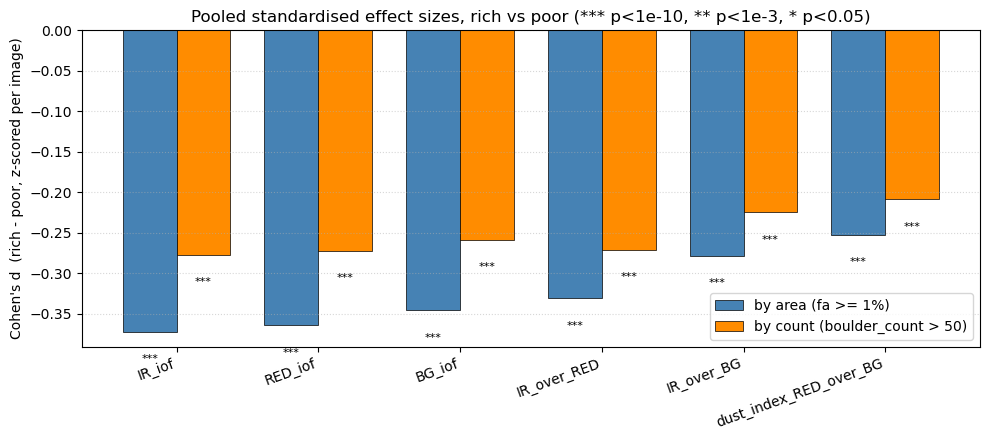

,partition_rule,feature,n_rich,n_poor,n_images_pooled,effect_size,p_value
1,P4_area,IR_iof,3306.0,5049.0,30,-0.372243,1.745860e-73
4,P4_area,RED_iof,3306.0,5049.0,30,-0.364749,5.057310e-69
7,P4_area,BG_iof,3306.0,5049.0,30,-0.346163,1.101394e-59
10,P4_area,IR_over_RED,3306.0,5049.0,30,-0.331352,1.686865e-61
13,P4_area,IR_over_BG,3306.0,5049.0,30,-0.278959,9.874763e-43
16,P4_area,dust_index_RED_over_BG,3306.0,5049.0,30,-0.252396,9.344625e-33
348,P2_count,IR_iof,4345.0,4650.0,33,-0.277397,3.456090e-45
351,P2_count,RED_iof,4345.0,4650.0,33,-0.272687,4.170039e-43
354,P2_count,BG_iof,4345.0,4650.0,33,-0.259147,1.155756e-36
357,P2_count,IR_over_RED,4345.0,4650.0,33,-0.271455,9.486667e-50


In [3]:
pooled_std = (results
    .query("level == 'pooled' and test_type == 'mann_whitney_standardised'")
    .copy())

def _annotate(ax, x, y, txt):
    ax.text(x, y, txt, fontsize=8, ha="center", va="bottom")

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(FEATURES))
width = 0.38
RULE_LABEL = {"P4_area": "by area (fa >= 1%)",
              "P2_count": "by count (boulder_count > 50)"}
for offset, rule, color in [(-width/2, "P4_area", "steelblue"),
                            (+width/2, "P2_count", "darkorange")]:
    sub = pooled_std[pooled_std["partition_rule"] == rule].set_index("feature").reindex(FEATURES)
    bars = ax.bar(x + offset, sub["effect_size"].to_numpy(), width=width,
                  label=RULE_LABEL[rule], color=color, edgecolor="black", linewidth=0.5)
    for xi, b, p in zip(x + offset, bars, sub["p_value"].to_numpy()):
        marker = "***" if p < 1e-10 else ("**" if p < 1e-3 else ("*" if p < 0.05 else "ns"))
        _annotate(ax, xi, b.get_height() + (0.01 if b.get_height() >= 0 else -0.04),
                  marker)
ax.axhline(0, color="k", linewidth=0.7)
ax.set_xticks(x)
ax.set_xticklabels(FEATURES, rotation=20, ha="right")
ax.set_ylabel("Cohen's d  (rich - poor, z-scored per image)")
ax.set_title("Pooled standardised effect sizes, rich vs poor "
             "(*** p<1e-10, ** p<1e-3, * p<0.05)")
ax.legend(loc="best")
ax.grid(True, axis="y", linestyle=":", alpha=0.5)
fig.tight_layout()
fig.savefig(FIG / "stage7d_pooled_effect_sizes.png", dpi=140, bbox_inches="tight")
plt.show()
pooled_std[["partition_rule", "feature", "n_rich", "n_poor",
            "n_images_pooled", "effect_size", "p_value"]]


## 4. Per-image effect-size distributions

The per-image MW + Cohen's d on raw features (no z-scoring), one row per
(eligible image x feature). This is the heterogeneity check: does the pooled
signal come from *every* image or is it driven by a few outliers?


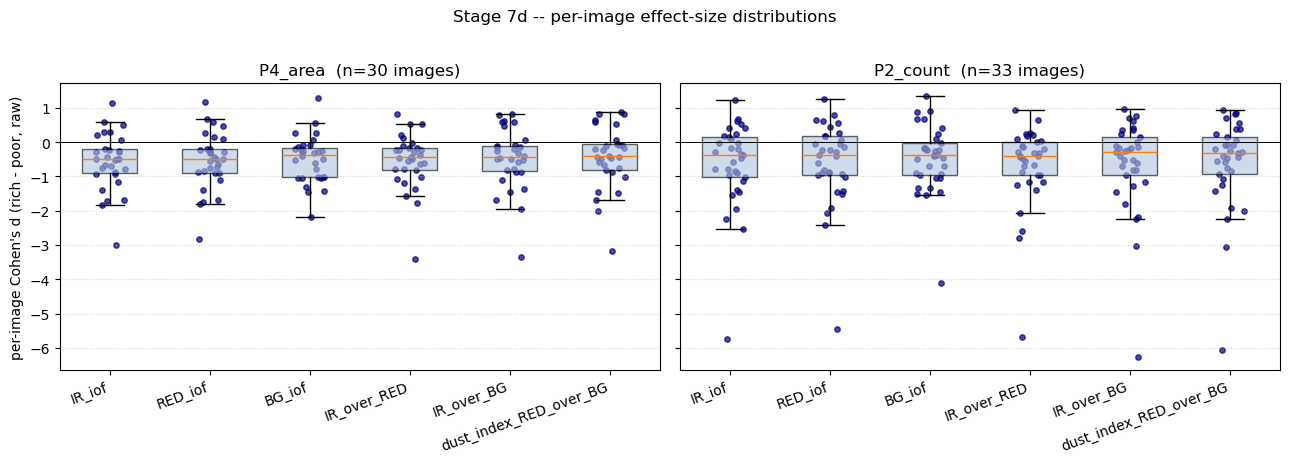

sum  count  frac_match
partition_rule feature                                       
P2_count       BG_iof                   25     33    0.757576
               IR_iof                   23     33    0.696970
               IR_over_BG               23     33    0.696970
               IR_over_RED              24     33    0.727273
               RED_iof                  23     33    0.696970
               dust_index_RED_over_BG   23     33    0.696970
P4_area        BG_iof                   25     30    0.833333
               IR_iof                   23     30    0.766667
               IR_over_BG               23     30    0.766667
               IR_over_RED              25     30    0.833333
               RED_iof                  23     30    0.766667
               dust_index_RED_over_BG   23     30    0.766667

In [4]:
per_image = (results
    .query("level == 'per_image' and test_type == 'mann_whitney_raw'")
    .copy())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, rule in zip(axes, ["P4_area", "P2_count"]):
    sub = per_image[per_image["partition_rule"] == rule]
    data = [sub[sub["feature"] == f]["effect_size"].dropna().to_numpy() for f in FEATURES]
    bp = ax.boxplot(data, positions=np.arange(len(FEATURES)),
                    widths=0.55, showfliers=False, patch_artist=True)
    for patch in bp["boxes"]:
        patch.set_facecolor("lightsteelblue"); patch.set_alpha(0.6)
    for i, d in enumerate(data):
        if len(d):
            ax.scatter(np.full_like(d, i, dtype=float) + np.random.uniform(-0.15, 0.15, size=len(d)),
                       d, s=15, alpha=0.7, color="navy")
    ax.axhline(0, color="k", linewidth=0.7)
    ax.set_xticks(np.arange(len(FEATURES)))
    ax.set_xticklabels(FEATURES, rotation=20, ha="right")
    n_img = sub["obs_id"].nunique()
    ax.set_title(f"{rule}  (n={n_img} images)")
    ax.grid(True, axis="y", linestyle=":", alpha=0.5)
axes[0].set_ylabel("per-image Cohen's d (rich - poor, raw)")
fig.suptitle("Stage 7d -- per-image effect-size distributions", y=1.02)
fig.tight_layout()
fig.savefig(FIG / "stage7d_per_image_effects.png", dpi=140, bbox_inches="tight")
plt.show()

# Per-image consistency: fraction with same-sign-as-pooled effect
pooled_sign = pooled_std.set_index(["partition_rule", "feature"])["effect_size"].apply(np.sign)
def _consistency(row):
    p = pooled_sign.get((row["partition_rule"], row["feature"]), 0)
    return np.sign(row["effect_size"]) == p
per_image["matches_pooled_sign"] = per_image.apply(_consistency, axis=1)
consistency = (per_image
    .groupby(["partition_rule", "feature"])["matches_pooled_sign"]
    .agg(["sum", "count"]))
consistency["frac_match"] = consistency["sum"] / consistency["count"]
consistency


## 5. Dust-confound discriminator (§5.2)

Per PLAN §5: a boulder-rich vs boulder-poor colour difference has two competing
explanations -- (1) **composition** (boulders expose primary igneous minerals
distinct from weathered alteration products), or (2) **dust** (less dust on/around
boulders, i.e. relative age of the deposit).

Discriminator: residualise each feature on `dust_index_RED_over_BG` per image,
then re-test rich vs poor on the residuals. If the difference **persists** after
controlling for dust, attribute the residual to composition; if it **collapses**,
attribute to dust.


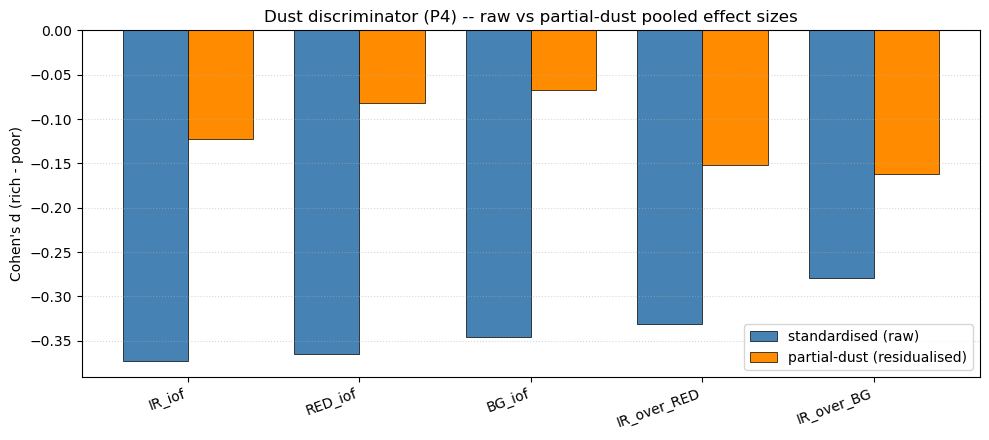

,raw_effect,raw_p,partial_effect,partial_p,shrinkage_frac
feature,,,,,
IR_iof,-0.372243,1.745860e-73,-0.122180,6.177797e-25,0.671774
RED_iof,-0.364749,5.057310e-69,-0.082314,9.133720e-18,0.774326
BG_iof,-0.346163,1.101394e-59,-0.067775,3.900519e-16,0.804212
IR_over_RED,-0.331352,1.686865e-61,-0.151663,8.489623e-18,0.542292
IR_over_BG,-0.278959,9.874763e-43,-0.161583,1.460961e-17,0.420765


In [5]:
raw = (results
    .query("level == 'pooled' and test_type == 'mann_whitney_standardised' "
           "and partition_rule == 'P4_area' and feature != 'dust_index_RED_over_BG'")
    .set_index("feature").reindex([f for f in FEATURES if f != 'dust_index_RED_over_BG']))
partial = (results
    .query("level == 'pooled' and test_type == 'mann_whitney_partial_dust' "
           "and partition_rule == 'P4_area'")
    .set_index("feature").reindex([f for f in FEATURES if f != 'dust_index_RED_over_BG']))

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(raw))
width = 0.38
ax.bar(x - width/2, raw["effect_size"].to_numpy(), width=width,
       label="standardised (raw)", color="steelblue", edgecolor="black", linewidth=0.5)
ax.bar(x + width/2, partial["effect_size"].to_numpy(), width=width,
       label="partial-dust (residualised)", color="darkorange", edgecolor="black", linewidth=0.5)
ax.axhline(0, color="k", linewidth=0.7)
ax.set_xticks(x)
ax.set_xticklabels(raw.index.tolist(), rotation=20, ha="right")
ax.set_ylabel("Cohen's d (rich - poor)")
ax.set_title("Dust discriminator (P4) -- raw vs partial-dust pooled effect sizes")
ax.legend(loc="best")
ax.grid(True, axis="y", linestyle=":", alpha=0.5)
fig.tight_layout()
fig.savefig(FIG / "stage7d_dust_discriminator.png", dpi=140, bbox_inches="tight")
plt.show()

ratio = pd.DataFrame({
    "raw_effect": raw["effect_size"],
    "raw_p": raw["p_value"],
    "partial_effect": partial["effect_size"],
    "partial_p": partial["p_value"],
    "shrinkage_frac": 1.0 - (partial["effect_size"].abs() / raw["effect_size"].abs()),
})
ratio


## 6. Continuous target -- Spearman vs `boulder_count` (§4.3)

Independent of any binary partition: do colour features correlate monotonically
with the continuous truth `boulder_count`? Per-image standardise the features
first, then Spearman rho across the pooled population. The partial-dust variant
residualises both feature and target on `dust_index_RED_over_BG` per image.


Pooled Spearman rho vs boulder_count (per-image standardised features):
feature                      BG_iof  IR_iof  IR_over_BG  IR_over_RED  RED_iof  \
test_type                                                                       
spearman_count_partial_dust  -0.122  -0.141      -0.119       -0.125   -0.123   
spearman_count_standardised  -0.141  -0.166      -0.140       -0.172   -0.159   

feature                      dust_index_RED_over_BG  
test_type                                            
spearman_count_partial_dust                     NaN  
spearman_count_standardised                  -0.123  


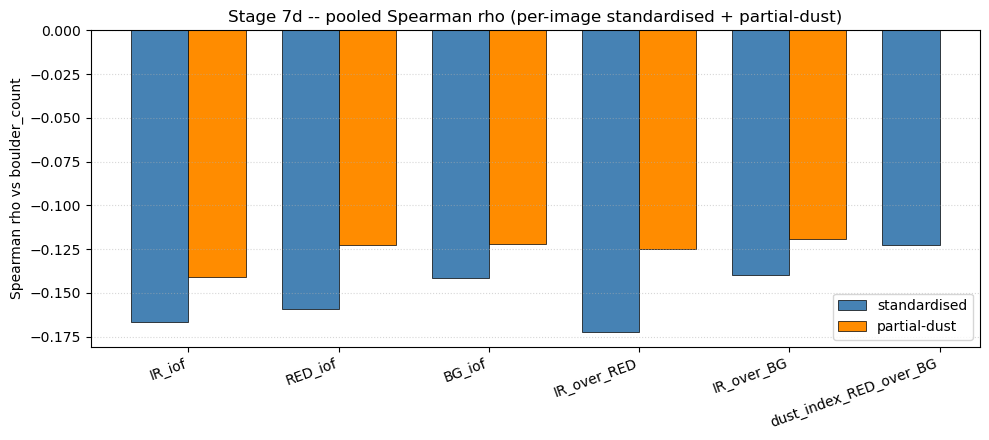

In [6]:
sp = (results
    .query("test_type.str.startswith('spearman_count')", engine="python")
    .copy())

pooled_sp = sp[sp["level"] == "pooled"].set_index(["test_type", "feature"])["effect_size"].unstack()
print("Pooled Spearman rho vs boulder_count (per-image standardised features):")
print(pooled_sp.round(3))

fig, ax = plt.subplots(figsize=(10, 4.5))
test_types = ["spearman_count_standardised", "spearman_count_partial_dust"]
colors = ["steelblue", "darkorange"]
width = 0.38
x = np.arange(len(FEATURES))
for off, tt, color in zip([-width/2, +width/2], test_types, colors):
    row = sp[(sp["level"] == "pooled") & (sp["test_type"] == tt)] \
        .set_index("feature").reindex(FEATURES)
    label = "standardised" if tt.endswith("standardised") else "partial-dust"
    ax.bar(x + off, row["effect_size"].to_numpy(), width=width,
           label=label, color=color, edgecolor="black", linewidth=0.5)
ax.axhline(0, color="k", linewidth=0.7)
ax.set_xticks(x); ax.set_xticklabels(FEATURES, rotation=20, ha="right")
ax.set_ylabel("Spearman rho vs boulder_count")
ax.set_title("Stage 7d -- pooled Spearman rho (per-image standardised + partial-dust)")
ax.legend(loc="best")
ax.grid(True, axis="y", linestyle=":", alpha=0.5)
fig.tight_layout()
fig.savefig(FIG / "stage7d_spearman_continuous.png", dpi=140, bbox_inches="tight")
plt.show()


## 7. Verdict against the PLAN §4 + §5 pass conditions

The pass conditions per PLAN §4 / §5 are (paraphrased):

1. **Cross-image significance** (§4.2): at least one colour feature shows
   statistically significant (|d| > 0.1, p < 1e-3) rich vs poor difference in the
   per-image standardised pooled test, with the same effect-size sign in the
   majority of per-image tests.
2. **Dust discrimination** (§5.2): of the features that pass (1), at least one
   retains a significant (p < 0.05, |d| > 0.05) effect after the per-image
   residualisation on `dust_index_RED_over_BG` -- i.e. the signal is not
   *entirely* attributable to differential dust loading.
3. **Continuous-target monotonicity** (§4.3): Spearman rho on the
   per-image-standardised features vs `boulder_count` aligns in sign with the
   binary result -- i.e. the signal scales with boulder density, not just with
   the threshold choice.

The cells below answer each question quantitatively against the pooled parquet.


In [7]:
def headline_pass(rule="P4_area", d_thresh=0.1, p_thresh=1e-3):
    pooled = results.query(
        "level == 'pooled' and test_type == 'mann_whitney_standardised' "
        "and partition_rule == @rule")
    passes = pooled[(pooled["effect_size"].abs() >= d_thresh)
                    & (pooled["p_value"] <= p_thresh)]
    return pooled, passes

pooled_p4, passes_p4 = headline_pass("P4_area")
pooled_p2, passes_p2 = headline_pass("P2_count")

print("=== Condition 1: cross-image significance (|d|>=0.1 & p<=1e-3) ===")
print(f"P4_area: {len(passes_p4)} / {len(pooled_p4)} features pass")
print(passes_p4[["feature", "effect_size", "p_value"]].to_string(index=False))
print()
print(f"P2_count: {len(passes_p2)} / {len(pooled_p2)} features pass")
print(passes_p2[["feature", "effect_size", "p_value"]].to_string(index=False))

# Per-image sign consistency
pooled_sign_p4 = pooled_p4.set_index("feature")["effect_size"].apply(np.sign)
def _sign_match(row):
    return np.sign(row["effect_size"]) == pooled_sign_p4.get(row["feature"], 0)
per_img_p4 = (results
    .query("level == 'per_image' and partition_rule == 'P4_area' "
           "and test_type == 'mann_whitney_raw'").copy())
per_img_p4["sign_match"] = per_img_p4.apply(_sign_match, axis=1)
consistency_p4 = per_img_p4.groupby("feature")["sign_match"].mean().reindex(FEATURES)
print("\n=== Per-image sign consistency vs pooled (P4) ===")
print(consistency_p4.round(2))


=== Condition 1: cross-image significance (|d|>=0.1 & p<=1e-3) ===
P4_area: 6 / 6 features pass
               feature  effect_size      p_value
                IR_iof    -0.372243 1.745860e-73
               RED_iof    -0.364749 5.057310e-69
                BG_iof    -0.346163 1.101394e-59
           IR_over_RED    -0.331352 1.686865e-61
            IR_over_BG    -0.278959 9.874763e-43
dust_index_RED_over_BG    -0.252396 9.344625e-33

P2_count: 6 / 6 features pass
               feature  effect_size      p_value
                IR_iof    -0.277397 3.456090e-45
               RED_iof    -0.272687 4.170039e-43
                BG_iof    -0.259147 1.155756e-36
           IR_over_RED    -0.271455 9.486667e-50
            IR_over_BG    -0.225103 4.682391e-32
dust_index_RED_over_BG    -0.208770 1.812834e-26

=== Per-image sign consistency vs pooled (P4) ===
feature
IR_iof                    0.77
RED_iof                   0.77
BG_iof                    0.83
IR_over_RED               0.83
IR_o

In [8]:
print("=== Condition 2: dust discrimination (|d|>=0.05 & p<=0.05 after partial-dust) ===")
partial_p4 = results.query(
    "level == 'pooled' and test_type == 'mann_whitney_partial_dust' "
    "and partition_rule == 'P4_area'")
survivors = partial_p4[(partial_p4["effect_size"].abs() >= 0.05)
                      & (partial_p4["p_value"] <= 0.05)]
print(f"P4_area: {len(survivors)} / {len(partial_p4)} features survive dust control")
print(survivors[["feature", "effect_size", "p_value"]].to_string(index=False))


=== Condition 2: dust discrimination (|d|>=0.05 & p<=0.05 after partial-dust) ===
P4_area: 5 / 5 features survive dust control
    feature  effect_size      p_value
     IR_iof    -0.122180 6.177797e-25
    RED_iof    -0.082314 9.133720e-18
     BG_iof    -0.067775 3.900519e-16
IR_over_RED    -0.151663 8.489623e-18
 IR_over_BG    -0.161583 1.460961e-17


In [9]:
print("=== Condition 3: continuous-target monotonicity ===")
sp_std = results.query(
    "level == 'pooled' and test_type == 'spearman_count_standardised'").set_index("feature")
sp_partial = results.query(
    "level == 'pooled' and test_type == 'spearman_count_partial_dust'").set_index("feature")
pooled_sign_p4 = pooled_p4.set_index("feature")["effect_size"].apply(np.sign)

mono = pd.DataFrame({
    "binary_d_sign": pooled_sign_p4.reindex(FEATURES),
    "spearman_rho_std": sp_std["effect_size"].reindex(FEATURES),
    "spearman_rho_partial_dust": sp_partial["effect_size"].reindex(FEATURES),
})
mono["sign_match_std"] = np.sign(mono["spearman_rho_std"]) == mono["binary_d_sign"]
mono["sign_match_partial"] = np.sign(mono["spearman_rho_partial_dust"]) == mono["binary_d_sign"]
print(mono.round(3))


=== Condition 3: continuous-target monotonicity ===
                        binary_d_sign  spearman_rho_std  \
feature                                                   
IR_iof                           -1.0            -0.166   
RED_iof                          -1.0            -0.159   
BG_iof                           -1.0            -0.141   
IR_over_RED                      -1.0            -0.172   
IR_over_BG                       -1.0            -0.140   
dust_index_RED_over_BG           -1.0            -0.123   

                        spearman_rho_partial_dust  sign_match_std  \
feature                                                             
IR_iof                                     -0.141            True   
RED_iof                                    -0.123            True   
BG_iof                                     -0.122            True   
IR_over_RED                                -0.125            True   
IR_over_BG                                 -0.119            

### Verdict summary

Read off the three cells above:

- **Condition 1 (cross-image significance)**: count of features passing the
  |d|>=0.1, p<=1e-3 bar under per-image standardisation, for both partition
  rules. Per-image sign consistency tells us whether the pooled signal is broad
  or driven by a few outliers.
- **Condition 2 (dust discrimination)**: count of features that survive the
  per-image residualisation on `dust_index_RED_over_BG`. Features that survive
  are the **compositional** signal; features whose effect collapses to ~0 are
  **dust-attributable** (i.e. relative-age, not composition).
- **Condition 3 (continuous monotonicity)**: Spearman rho on the
  per-image-standardised features vs `boulder_count`, sign-matched against the
  binary effect direction. Same-sign agreement means the colour signal scales
  with boulder density, not just with the partition threshold.

Combine the three with the **per-image effect-size box plot** (§4) -- a verdict
of "compositional signal supported" requires at least one feature passing all
three conditions AND broad per-image agreement.

The Stage 7e refinement (formal Atwood-Stone & McEwen 2013 dust index +
Stage 4b shadow-fraction masking) can now be prioritised based on which
specific features carry the residual after dust control.
